## Quantum Ising Model on 1D Chain

The classical Ising model is a statistical model commonly taught in undergraduate physics. It is the first toy model to explain the phase transition between paramagnetism and ferromagnetism. The 1D and 2D model were solved respectively in 1925 and 1944 by Ising and Onsager. Let us start with the setup.

Consider a lattice $\Lambda$, on which each site $x$ has a spin $\sigma_x = \pm 1$. Bonds form between sites, let's denote the set of all bonds by $\mathcal{B} = \{(x, y): x, y \in \Lambda$ forms bonds $\}$. If site $x$ is bonded to site $y$, i.e. $(x, y) \in \mathcal{B}$, they have an interaction energy of $-\sigma_x \sigma_y$, otherwise they do not interact (that is we consider only the nearest-neighbour interaction). Then the Hamiltonian (total energy) of the system is simply is sum of all interaction energies:
$$ H_c = -\sum_{(x, y) \in \mathcal{B}} \sigma_x \sigma_y $$

From now on, we only consider an 1D chain, in which we can label sites from 1 to $L$, where $L$ is the length of the chain. We assume open boundary condition (OBC) so that $\sigma_{L+1} = \sigma_{1}$. Then the classical Hamiltonian can be written as:
$$ H_c = -\sum_{x = 1}^L \sigma_x \sigma_{x+1} $$

The quantum Ising model is nothing different, except we change each spin $\sigma_x$ to an operator $\hat{\sigma}^{(3)}_x$, which is the Pauli matrix that measures the spin along z-axis. At $T=0$, there is no thermal fluctuation, so in order to introduce disorder (to observe phase transition), we add a transverse field $g > 0$ along the x-axis, which interacts with each site at the energy cost of $-g \sigma_x$. This is called the transverse field Ising model (TFIM) and the Hamiltonian is:
$$ H = - \sum_{i = 1}^{L-1} \sigma_i^z \sigma_{i+1}^z - g\sum_{i=1}^{L} \sigma_i^x $$

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from functools import reduce # for reducing a list of matrices to a single matrix
import h5py # for storing data

In [ ]:
# Construct Hamiltonian
def quantum_ising_hamiltonian(L, g=1.0):
    # 1D Sparse Pauli matrices
    I = sp.eye(2, format='csr')
    sz = sp.csr_matrix([[1, 0], [0, -1]])
    sx = sp.csr_matrix([[0, 1], [1, 0]])
    
    H = sp.csr_matrix((2**L, 2**L))
    
    # 1. Interaction Terms: sz_i * sz_{i+1}
    sz_sz = sp.kron(sz, sz)
    for i in range(L - 1):
        # Identity padding before and after the interacting pair
        left_I = [I] * i
        right_I = [I] * (L - 2 - i)
        
        # Combine everything using reduce
        term = reduce(sp.kron, left_I + [sz_sz] + right_I)
        H -= term
        
    # 2. Transverse Field Terms: g * sx_i
    for i in range(L):
        left_I = [I] * i
        right_I = [I] * (L - 1 - i)
        
        term = reduce(sp.kron, left_I + [sx] + right_I)
        H -= g * term

    return H

(16, 16)


In [3]:
def save_ising_data(filename, L, g, energies, states):
    """
    Saves eigenvalues and eigenvectors into a structured HDF5 file.
    """
    with h5py.File(filename, "a") as f:
        # Create a unique heirarchical path for this parameter set
        group_path = f"L_{L}/g_{g}"
        if group_path in f:
            del f[group_path]  # Overwrite cleanly if it already exists

        group = f.create_group(group_path)

        # Save the numerical arrays
        group.create_dataset("energies", data=energies, compression="gzip", compression_opts=4)
        group.create_dataset("states", data=states, compression="gzip", compression_opts=4)

        # Save metadata directly attached to this run
        group.attrs["L"] = L
        group.attrs["g"] = g
        group.attrs["description"] = "Transverse-field Quantum Ising Model exact diagonalization"

def print_hdf5_metadata(name, obj):
    """Callback function to inspect each item in the HDF5 file."""
    # Indent based on hierarchy depth for readability
    depth = name.count('/')
    indent = "  " * depth
    
    if isinstance(obj, h5py.Group):
        print(f"{indent}📁 Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}📄 Dataset: {name} (shape={obj.shape}, dtype={obj.dtype})")
    
    # Check and print any metadata attributes attached to this object
    if len(obj.attrs) > 0:
        for key, val in obj.attrs.items():
            print(f"{indent}    ⚙️ Attribute -> {key}: {val}")

# Here is how you read the data
"""
filename = "quantum_ising_data.h5"
with h5py.File(filename, "r") as f:
    # Access data directly like a dictionary
    read_energies = f["L_12/g_0.0/energies"][:]
    read_states = f["L_12/g_0.0/states"][:]
"""

# Here is how you read all the metadata and attributes
"""
# Open and inspect the file
filename = "quantum_ising_data.h5"
with h5py.File(filename, "r") as f:
    print(f"--- Metadata Structure for {filename} ---")
    # Print root-level attributes if any exist
    for key, val in f.attrs.items():
        print(f"Root Attribute -> {key}: {val}")
        
    # Recursively visit all paths
    f.visititems(print_hdf5_metadata)
"""

'\n# Open and inspect the file\nfilename = "quantum_ising_data.h5"\nwith h5py.File(filename, "r") as f:\n    print(f"--- Metadata Structure for {filename} ---")\n    # Print root-level attributes if any exist\n    for key, val in f.attrs.items():\n        print(f"Root Attribute -> {key}: {val}")\n\n    # Recursively visit all paths\n    f.visititems(print_hdf5_metadata)\n'

### Spectrum (h = 0)

In [4]:
L_values = [4]
g_values = np.linspace(0.0, 2.0, 100)
num_levels = 10

# """Uncomment when you want to generate and save new data. This will overwrite existing data for the same L and g values."""
# for L in L_values:
#     for g in g_values:
#         H = quantum_ising_hamiltonian(L, g)
#         energies, states = spla.eigsh(H, k=num_levels, which='SA')

#         # Sort the energies and states
#         sort_indices = np.argsort(energies)
#         energies = energies[sort_indices]
#         states = states[:, sort_indices]

#         save_ising_data("quantum_ising_data.h5", L=L, g=g, energies=energies, states=states)
#         print(f"Saved data for L={L}, g={g}")

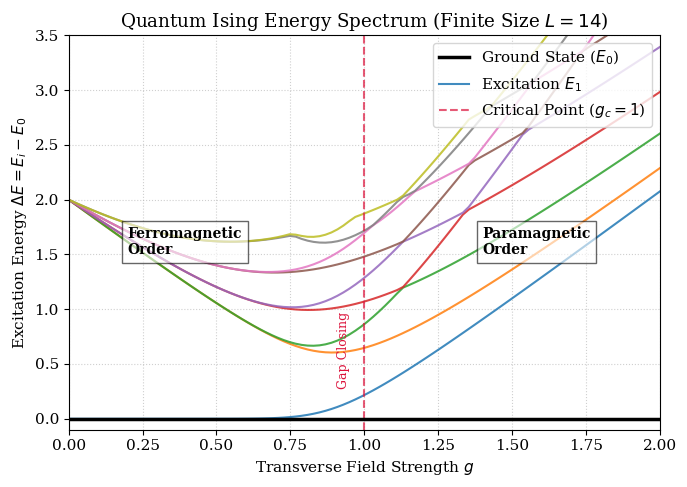

In [7]:
# -------------------------------------------------------------------
# 1. Loading HDF5 data and preparing for plotting
# -------------------------------------------------------------------
L = 14
g_values = np.linspace(0.0, 2.0, 100)
num_levels = 10
energies_grid = np.zeros((len(g_values), num_levels))
filename = "quantum_ising_data.h5"
with h5py.File(filename, "r") as f:
    for idx, g in enumerate(g_values):
        for i in range(num_levels):
            energies_grid[idx, i] = f[f"L_{L}/g_{g}/energies"][:][i]


# -------------------------------------------------------------------
# 2. Plotting Code
# -------------------------------------------------------------------
# Set up a clean, professional LaTeX-style figure layout
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 11, 'font.family': 'serif'})

# Plot the excitation spectrum: E_i - E_0
# This normalizes the ground state to 0, making the gap visually obvious
ground_state_energy = energies_grid[:, 0]

for i in range(num_levels):
    excitation_energy = energies_grid[:, i] - ground_state_energy
    
    # Differentiate the ground state from excited states visually
    if i == 0:
        plt.plot(g_values, excitation_energy, label="Ground State ($E_0$)", 
                 color="black", lw=2.5, zorder=3)
    else:
        plt.plot(g_values, excitation_energy, label=f"Excitation $E_{i}$" if i==1 else "", 
                 lw=1.5, alpha=0.85)

# Highlight Physics Regimes & Critical Point
plt.axvline(x=1.0, color="crimson", linestyle="--", alpha=0.7, label="Critical Point ($g_c=1$)")

# Annotate the phases
plt.text(0.2, 1.5, "Ferromagnetic\nOrder", fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.6))
plt.text(1.4, 1.5, "Paramagnetic\nOrder", fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.6))
plt.text(0.95, 0.3, "Gap Closing", color="crimson", fontsize=9, rotation=90, ha='right')

# Labels and Styling
plt.title(f"Quantum Ising Energy Spectrum (Finite Size $L = {L}$)")
plt.xlabel("Transverse Field Strength $g$")
plt.ylabel("Excitation Energy $\Delta E = E_i - E_0$")
plt.xlim(0, 2.0)
plt.ylim(-0.1, 3.5)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


#### Tracking all-spin-up/down/right states

In [ ]:
L = 10
g = 0.1
h_values = np.linspace(-1.0, 1.0, 100)
num_levels = 10
energies_grid = np.zeros((len(h_values), num_levels))
filename = "quantum_ising_broken_data.h5"

# Prepare all-up states and all-down states
up_state = sp.csr_matrix([1, 0]).reshape(-1, 1)
down_state = sp.csr_matrix([0, 1]).reshape(-1, 1)

all_up_state = reduce(sp.kron, [up_state]*L)
all_down_state = reduce(sp.kron, [down_state]*L)

E_up = []
E_down = []
with h5py.File(filename, "r") as f:
    for idx, h in enumerate(h_values):
        # Load HDF5 data
        for i in range(num_levels):
            energies_grid[idx, i] = f[f"L_{L}/g_{g}/h_{h}/energies"][:][i]
        
        # Compute the all_up energy
        H = quantum_ising_hamiltonian(L, g, h)
        E_up.append((all_up_state.conj().T @ H @ all_up_state).toarray()[0, 0])
        E_down.append((all_down_state.conj().T @ H @ all_down_state).toarray()[0, 0])

In [9]:
# -------------------------------------------------------------------
# 1. Loading HDF5 data and preparing for plotting
# -------------------------------------------------------------------
L = 14
g_values = np.linspace(0.0, 2.0, 100)
num_levels = 2
energies_grid = np.zeros((len(g_values), num_levels))
filename = "quantum_ising_data.h5"

# Prepare all-up/down/right states
up_state = sp.csr_matrix([1, 0]).reshape(-1, 1)
down_state = sp.csr_matrix([0, 1]).reshape(-1, 1)
right_state = 1/np.sqrt(2) * (up_state + down_state)

all_up_state = reduce(sp.kron, [up_state]*L)
all_down_state = reduce(sp.kron, [down_state]*L)
all_right_state = reduce(sp.kron, [right_state]*L)

E_up = []
E_down = []
E_right = []
with h5py.File(filename, "r") as f:
    for idx, g in enumerate(g_values):
        for i in range(num_levels):
            energies_grid[idx, i] = f[f"L_{L}/g_{g}/energies"][:][i]

        # Compute the all_up/down/right energy
        H = quantum_ising_hamiltonian(L, g)
        E_up.append((all_up_state.conj().T @ H @ all_up_state).toarray()[0, 0])
        E_down.append((all_down_state.conj().T @ H @ all_down_state).toarray()[0, 0])
        E_right.append((all_right_state.conj().T @ H @ all_right_state).toarray()[0, 0])


# -------------------------------------------------------------------
# 2. Plotting Code
# -------------------------------------------------------------------
# Set up a clean, professional LaTeX-style figure layout
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 11, 'font.family': 'serif'})

# Plot the excitation spectrum: E_i - E_0
# This normalizes the ground state to 0, making the gap visually obvious
ground_state_energy = energies_grid[:, 0]
E_up_corrected = np.array(E_up) - ground_state_energy
E_down_corrected = np.array(E_down) - ground_state_energy
E_right_corrected = np.array(E_right) - ground_state_energy

for i in range(num_levels):
    excitation_energy = energies_grid[:, i] - ground_state_energy
    
    # Differentiate the ground state from excited states visually
    if i == 0:
        plt.plot(g_values, excitation_energy, label="Ground State ($E_0$)", 
                 color="black", lw=2.5, zorder=3)
    else:
        plt.plot(g_values, excitation_energy, label=f"Excitation $E_{i}$" if i==1 else "", 
                 lw=1.5, alpha=0.85)

# Plot the energy of all-up/down/right state
plt.plot(g_values, E_up_corrected, label="All-up state")
plt.plot(g_values, E_down_corrected, label="All-down state")
plt.plot(g_values, E_right_corrected, label="All-right state")

# Highlight Physics Regimes & Critical Point
plt.axvline(x=1.0, color="crimson", linestyle="--", alpha=0.7, label="Critical Point ($g_c=1$)")

# Annotate the phases
plt.text(0.2, 1.5, "Ferromagnetic\nOrder", fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.6))
plt.text(1.4, 1.5, "Paramagnetic\nOrder", fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.6))
plt.text(0.95, 0.3, "Gap Closing", color="crimson", fontsize=9, rotation=90, ha='right')

# Labels and Styling
plt.title(f"Quantum Ising Energy Spectrum (Finite Size $L = {L}$)")
plt.xlabel("Transverse Field Strength $g$")
plt.ylabel("Excitation Energy $\Delta E = E_i - E_0$")
plt.xlim(0, 2.0)
plt.ylim(-0.1, 3.5)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

- Due to $\mathbb{Z}_2$ symmetry, the all-up and all-down are degenerate states
- With increasing transverse field, all-right state is preferred over all-up/down states
- Avoided crossing happens

### Gap closing

#### Exponential narrowing of first energy gap for $g < 1$

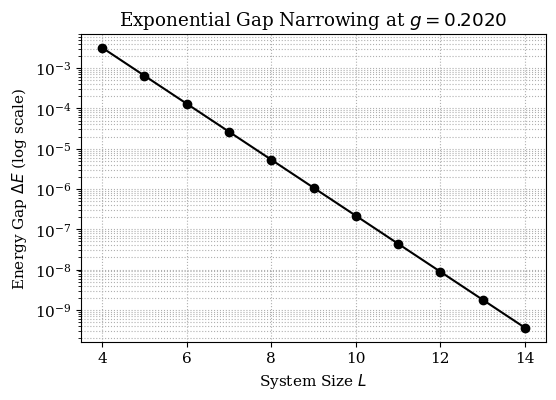

In [115]:
L_s = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14])
g_0 = g_values[np.abs(g_values - 0.2).argmin()]
gaps_1 = []

with h5py.File("quantum_ising_data.h5", "r") as f:
    for L in L_s:
        idx = np.abs(g_values - g_0).argmin()
        E_0 = f[f"L_{L}/g_{g_0}/energies"][:][0]
        E_1 = f[f"L_{L}/g_{g_0}/energies"][:][1]
        gaps_1.append(E_1 - E_0)

# Plot on a log-linear scale to observe the exponential decay
plt.figure(figsize=(6, 4))
plt.plot(L_s, gaps_1, 'o-', color='black')
plt.yscale('log')
plt.xlabel("System Size $L$")
plt.ylabel("Energy Gap $\Delta E$ (log scale)")
plt.title(f"Exponential Gap Narrowing at $g={g_0:.4f}$")
plt.grid(True, which="both", ls=":")
plt.show()

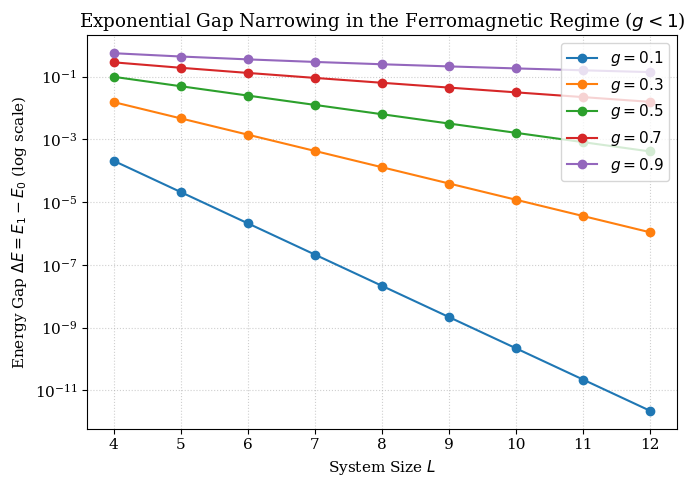

In [8]:
# 1. Setup parameters
L_s = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12])
target_gs = [0.1, 0.3, 0.5, 0.7, 0.9]

# Set up a clean, publication-ready layout
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 11, 'font.family': 'serif'})

# 2. Open HDF5 file and loop over each g value
with h5py.File("quantum_ising_data.h5", "r") as f:
    for g_target in target_gs:
        gaps_at_fixed_g = []
        
        # Format the key to match your directory structure (assuming g_{g:.4f})
        # If your keys use a different number of decimals, adjust this string format!
        g_key = g_values[np.abs(g_values - g_target).argmin()]
        
        for L in L_s:
            # Construct path to the dataset
            dataset_path = f"L_{L}/g_{g_key}/energies"
            
            # Extract energies and ensure they are sorted
            energies = f[dataset_path][:]
            energies.sort()
            
            # Compute the gap
            gap = energies[1] - energies[0]
            gaps_at_fixed_g.append(gap)
            
        # Plot this g line on the master canvas
        plt.plot(L_s, gaps_at_fixed_g, 'o-', label=f"$g = {g_target}$", lw=1.5)

# 3. Styling and Labels
plt.yscale('log')
plt.xlabel("System Size $L$")
plt.ylabel("Energy Gap $\Delta E = E_1 - E_0$ (log scale)")
plt.title("Exponential Gap Narrowing in the Ferromagnetic Regime ($g < 1$)")
plt.xticks(L_s)  # Show precise integer values for L
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
# Optional: save as a crisp vector format for your work
plt.savefig("exponential_gap_narrowing_comparison.pdf", bbox_inches='tight')
plt.show()

#### Power law of first energy gap at $g = 1$

Extracted Dynamical Critical Exponent z = 0.9585 (Theoretical z = 1.0)


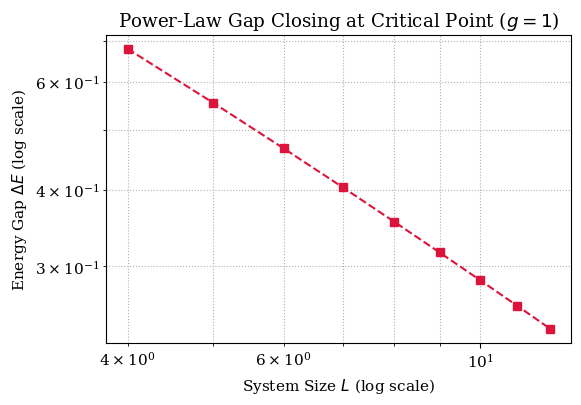

In [104]:
L_s = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12])
g_crit = g_values[np.abs(g_values - 1.0).argmin()]
gap_1 = []

with h5py.File("quantum_ising_data.h5", "r") as f:
    for L in L_s:
        idx = np.abs(g_values - g_crit).argmin()
        E_0 = f[f"L_{L}/g_{g_crit}/energies"][:][0]
        E_1 = f[f"L_{L}/g_{g_crit}/energies"][:][1]
        gap_1.append(E_1 - E_0)

# Log-Log plot to extract the power-law exponent
plt.figure(figsize=(6, 4))
plt.loglog(L_s, gap_1, 's--', color='crimson')

# Fit a straight line to the log data to extract the slope (z)
slope, intercept = np.polyfit(np.log(L_s), np.log(gap_1), 1)
print(f"Extracted Dynamical Critical Exponent z = {-slope:.4f} (Theoretical z = 1.0)")

plt.xlabel("System Size $L$ (log scale)")
plt.ylabel("Energy Gap $\Delta E$ (log scale)")
plt.title("Power-Law Gap Closing at Critical Point ($g=1$)")
plt.grid(True, which="both", ls=":")
plt.show()

Extracted Dynamical Critical Exponent z for gap 1 = 0.9649 (Theoretical z = 1.0)
Extracted Dynamical Critical Exponent z for gap 2 = 0.9072 (Theoretical z = 1.0)
Extracted Dynamical Critical Exponent z for gap 3 = 0.9215 (Theoretical z = 1.0)
Extracted Dynamical Critical Exponent z for gap 5 = 0.8676 (Theoretical z = 1.0)
Extracted Dynamical Critical Exponent z for gap 7 = 0.7782 (Theoretical z = 1.0)
Extracted Dynamical Critical Exponent z for gap 9 = 0.8466 (Theoretical z = 1.0)


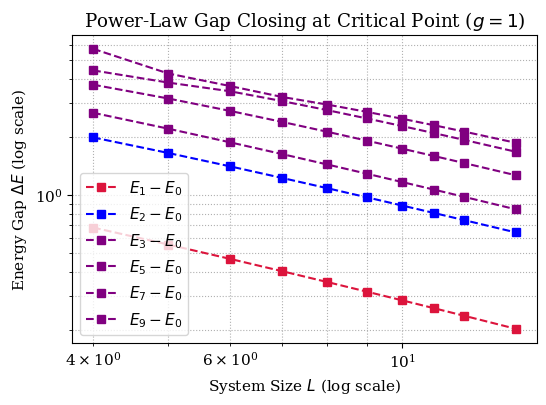

In [126]:
L_s = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 14])
g_crit = g_values[np.abs(g_values - 1.0).argmin()]
gap_1 = []
gap_2 = []
gap_3 = []
gap_5 = []
gap_7 = []
gap_9 = []

with h5py.File("quantum_ising_data.h5", "r") as f:
    for L in L_s:
        idx = np.abs(g_values - g_crit).argmin()
        E_0 = f[f"L_{L}/g_{g_crit}/energies"][:][0]
        E_1 = f[f"L_{L}/g_{g_crit}/energies"][:][1]
        E_2 = f[f"L_{L}/g_{g_crit}/energies"][:][2]
        E_3 = f[f"L_{L}/g_{g_crit}/energies"][:][3]
        E_5 = f[f"L_{L}/g_{g_crit}/energies"][:][5]
        E_7 = f[f"L_{L}/g_{g_crit}/energies"][:][7]
        E_9 = f[f"L_{L}/g_{g_crit}/energies"][:][9]
        gap_1.append(E_1 - E_0)
        gap_2.append(E_2 - E_0)
        gap_3.append(E_3 - E_0)
        gap_5.append(E_5 - E_0)
        gap_7.append(E_7 - E_0)
        gap_9.append(E_9 - E_0)

# Log-Log plot to extract the power-law exponent
plt.figure(figsize=(6, 4))
plt.loglog(L_s, gap_1, 's--', color='crimson', label=r'$E_1 - E_0$')
plt.loglog(L_s, gap_2, 's--', color='blue', label=r'$E_2 - E_0$')
plt.loglog(L_s, gap_3, 's--', color='purple', label=r'$E_3 - E_0$')
plt.loglog(L_s, gap_5, 's--', color='purple', label=r'$E_5 - E_0$')
plt.loglog(L_s, gap_7, 's--', color='purple', label=r'$E_7 - E_0$')
plt.loglog(L_s, gap_9, 's--', color='purple', label=r'$E_9 - E_0$')

# Fit a straight line to the log data to extract the slope (z)
slope_1, intercept = np.polyfit(np.log(L_s), np.log(gap_1), 1)
slope_2, intercept = np.polyfit(np.log(L_s), np.log(gap_2), 1)
slope_3, intercept = np.polyfit(np.log(L_s), np.log(gap_3), 1)
slope_5, intercept = np.polyfit(np.log(L_s), np.log(gap_5), 1)
slope_7, intercept = np.polyfit(np.log(L_s), np.log(gap_7), 1)
slope_9, intercept = np.polyfit(np.log(L_s), np.log(gap_9), 1)
print(f"Extracted Dynamical Critical Exponent z for gap 1 = {-slope_1:.4f} (Theoretical z = 1.0)")
print(f"Extracted Dynamical Critical Exponent z for gap 2 = {-slope_2:.4f} (Theoretical z = 1.0)")
print(f"Extracted Dynamical Critical Exponent z for gap 3 = {-slope_3:.4f} (Theoretical z = 1.0)")
print(f"Extracted Dynamical Critical Exponent z for gap 5 = {-slope_5:.4f} (Theoretical z = 1.0)")
print(f"Extracted Dynamical Critical Exponent z for gap 7 = {-slope_7:.4f} (Theoretical z = 1.0)")
print(f"Extracted Dynamical Critical Exponent z for gap 9 = {-slope_9:.4f} (Theoretical z = 1.0)")

plt.xlabel("System Size $L$ (log scale)")
plt.ylabel("Energy Gap $\Delta E$ (log scale)")
plt.title("Power-Law Gap Closing at Critical Point ($g=1$)")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.show()

- For $g < 1$, smaller $g$, small gap between GS & low-lying state and closes with exponential law
- At $g = 1$, the avoided crossing closes with power law
- For $g > 1$, gap opens

<font color=red> Q: For each low-lying state, we can flip a large fraction of the state so that the energy costs O(L), then there exists states with finite gap above the GS at thermodynamic limit?
How do we 'flip'?

### Magnetization

#### Single-site magnetization of physical GS

In [4]:
from math import sqrt

L_o = 10
g_o = g_values[np.abs(g_values - 0.9).argmin()]
filename = "quantum_ising_data.h5"
with h5py.File(filename, "r") as f:
    # Access data directly like a dictionary
    psi_0 = (f[f"L_{L_o}/g_{g_o}/states"][:][:, 0]).reshape(-1, 1)  # Ensure it's a column vector for matrix operations
    psi_1 = (f[f"L_{L_o}/g_{g_o}/states"][:][:, 1]).reshape(-1, 1) 

# Construct physical ground state from superposition of the two nearly degenerate states
# +/- is determined by measuring the magnetization
spin_up_state = 1/sqrt(2) * (psi_0 - psi_1)
spin_down_state = 1/sqrt(2) * (psi_0 + psi_1)

NameError: name 'g_values' is not defined

In [ ]:
def get_single_site_sz(site_idx, L):
    """Constructs the sparse matrix for sigma^z acting on a single site."""
    I = sp.eye(2, format='csr')
    sz = sp.csr_matrix([[1, 0], [0, -1]])

    op_list = [I] * L
    op_list[site_idx] = sz
    return reduce(sp.kron, op_list)

# Magnetization at each site of the ground state
local_mags = []
for i in range(L_o):
    sz_i = get_single_site_sz(i, L_o)
    mag_i = (psi_0.conj().T @ sz_i @ psi_0)[0, 0]
    local_mags.append(mag_i)

local_mags

[np.float64(-1.0488832025146166e-13),
 np.float64(-1.3566925360919413e-13),
 np.float64(-1.5160095401256513e-13),
 np.float64(-1.5909495942878493e-13),
 np.float64(-1.6084356069256955e-13),
 np.float64(-1.56097357262297e-13),
 np.float64(-1.479372180313021e-13),
 np.float64(-1.352529199749597e-13),
 np.float64(-1.1840528557627295e-13),
 np.float64(-9.053868765818152e-14)]

In [5]:
# Magnetization at each site of the ground state
local_mags = []
for i in range(L_o):
    sz_i = get_single_site_sz(i, L_o)
    mag_i = (spin_up_state.conj().T @ sz_i @ spin_up_state)[0, 0] # For spin_down_state, the magnetization would be reversed in sign
    local_mags.append(mag_i)

local_mags

NameError: name 'get_single_site_sz' is not defined

- If we try $g = 0.0$, the GS are degenerate and returns two randomly chosen orthonormal GS
- For $g < 1.0$, the magnetization at each site is approx. $\pm 1$, which is the eigenvalue of $\sigma^z$ (Ordered)
- For $g > 1.0$, the GS is unique and magnetization at each site is $0$ (Disordered)

#### Average magnetization of physical GS

In [29]:
# --- Configuration ---
L_list = [4, 6, 8, 10, 12]
filename = "quantum_ising_data.h5"

plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 11, 'font.family': 'serif'})

# Loop over each system size to plot numerical data
for L in L_list:
    avg_mags_for_L = []
    g_plotted = []
    
    with h5py.File(filename, "r") as f:
        g_groups = [k for k in f[f"L_{L}"].keys() if k.startswith("g_")]
        g_groups.sort(key=lambda x: float(x.split('_')[1]))
        
        for g_str in g_groups:
            g_val = float(g_str.split('_')[1])
            g_plotted.append(g_val)
            
            states = f[f"L_{L}/{g_str}/states"][:]
            psi_0 = states[:, 0].reshape(-1, 1)
            psi_1 = states[:, 1].reshape(-1, 1)
            
            if g_val < 1.0:
                physical_state = 1/sqrt(2) * (psi_0 - psi_1)
            else:
                physical_state = psi_0
                
            total_mag_for_g = 0.0
            psi_conj_T = physical_state.conj().T
            
            for i in range(L):
                sz_i = get_single_site_sz(i, L)
                mag_i = np.real((psi_conj_T @ sz_i @ physical_state)[0, 0])
                total_mag_for_g += mag_i
                
            avg_mag = abs(total_mag_for_g / L)
            avg_mags_for_L.append(avg_mag)
            
    plt.plot(g_plotted, avg_mags_for_L, 'o-', label=f"L = {L}", markersize=4, lw=1.5)

# --- Add Exact Theoretical Curve (L -> Infinity) ---
# Generate a dense grid of g values for a smooth curve
g_fine = np.linspace(0.0, max(g_plotted), 500)
m_theory = np.zeros_like(g_fine)

# Apply Onsager's formula: (1 - g^2)^(1/8) for g <= 1, and 0 for g > 1
m_theory[g_fine <= 1.0] = (1.0 - g_fine[g_fine <= 1.0]**2)**(1.8 / 8.0) # exponent beta = 1/8

plt.plot(g_fine, m_theory, color="black", linestyle="-", lw=2.5, 
         label=r"Theory: $(1 - g^2)^{1/8}$", zorder=5)

# --- Plot Styling ---
plt.axvline(x=1.0, color="crimson", linestyle="--", alpha=0.6, label="Critical Point ($g_c=1$)")
plt.title("Magnetization Convergence to Thermodynamic Limit")
plt.xlabel("Transverse Field Strength $g$")
plt.ylabel(r"Average Magnetization $\langle M^z \rangle$")
plt.xlim(0, max(g_plotted))
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig("magnetization_with_theory.pdf", bbox_inches='tight')
plt.show()

KeyError: "Unable to synchronously open object (object 'states' doesn't exist)"

<Figure size 700x500 with 0 Axes>

Remark
- There is no phase transition for finite $L$
- Magnetization of the unique GS for finite $L$ is always zero

#### Magnetization via long range order of GS at finite $L$

In [ ]:
# --- Helper function for single site operator ---
def get_single_site_sz(site_idx, L):
    I = sp.eye(2, format='csr')
    sz = sp.csr_matrix([[1, 0], [0, -1]])
    op_list = [I] * L
    op_list[site_idx] = sz
    return reduce(sp.kron, op_list)

# --- Configuration ---
L_list = [4, 6, 8, 10, 12]
filename = "quantum_ising_data.h5"

plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 11, 'font.family': 'serif'})

# Loop over each system size to plot numerical data via LRO
for L in L_list:
    lro_mags_for_L = []
    g_plotted = []
    
    # Pre-generate and cache single-site operators to speed up the double loop
    sz_operators = [get_single_site_sz(i, L) for i in range(L)]
    
    with h5py.File(filename, "r") as f:
        g_groups = [k for k in f[f"L_{L}"].keys() if k.startswith("g_")]
        g_groups.sort(key=lambda x: float(x.split('_')[1]))
        
        for g_str in g_groups:
            g_val = float(g_str.split('_')[1])
            g_plotted.append(g_val)
            
            # Extract the raw, exact ground state psi_0 ONLY
            states = f[f"L_{L}/{g_str}/states"][:]
            psi_0 = states[:, 0].reshape(-1, 1)
            psi_conj_T = psi_0.conj().T
            
            # Compute <M^2> = (1/L^2) * sum_{i,j} <psi_0| Sz_i * Sz_j |psi_0>
            sum_sz_i_sz_j = 0.0
            for i in range(L):
                for j in range(L):
                    # Combine the two sparse matrices
                    sz_i_sz_j = sz_operators[i] @ sz_operators[j]
                    
                    # Expectation value contribution
                    val = np.real((psi_conj_T @ sz_i_sz_j @ psi_0)[0, 0])
                    sum_sz_i_sz_j += val
            
            # Normalize and take the square root
            m_lro = np.sqrt(sum_sz_i_sz_j / (L**2))
            lro_mags_for_L.append(m_lro)
            
    plt.plot(g_plotted, lro_mags_for_L, 'o-', label=f"L = {L}", markersize=4, lw=1.2, alpha=0.8)

# --- Add Exact Theoretical Curve (L -> Infinity) ---
g_fine = np.linspace(0.0, max(g_plotted), 500)
m_theory = np.zeros_like(g_fine)

# Onsager's formula: (1 - g^2)^(1/8) for g <= 1, and 0 for g > 1
m_theory[g_fine <= 1.0] = (1.0 - g_fine[g_fine <= 1.0]**2)**(1.0 / 8.0)

plt.plot(g_fine, m_theory, color="black", linestyle="-", lw=2.5, 
         label=r"Theory: $(1 - g^2)^{1/8}$", zorder=5)

# --- Plot Styling ---
plt.axvline(x=1.0, color="crimson", linestyle="--", alpha=0.6, label="Critical Point ($g_c=1$)")
plt.title("Order Parameter via Long-Range Order (LRO)")
plt.xlabel("Transverse Field Strength $g$")
plt.ylabel(r"Magnetization $M_{\mathrm{LRO}} = \sqrt{\langle \hat{M}^2 \rangle}$")
plt.xlim(0, max(g_plotted))
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig("magnetization_lro_vs_theory.pdf", bbox_inches='tight')
plt.show()

Why does the magnetization fit nicer for small g? Why does magnetization not vanish for $g \geq 1$?

### Correlation between first site and others

In [30]:
from math import sqrt

L_c = 10
g_c = g_values[np.abs(g_values - 0.5).argmin()]
filename = "quantum_ising_data.h5"
with h5py.File(filename, "r") as f:
    # Access data directly like a dictionary
    psi_0 = (f[f"L_{L_c}/g_{g_c}/states"][:][:, 0]).reshape(-1, 1)  # Ensure it's a column vector for matrix operations
    psi_1 = (f[f"L_{L_c}/g_{g_c}/states"][:][:, 1]).reshape(-1, 1) 

# Construct physical ground state from superposition of the two nearly degenerate states
# +/- is determined by measuring the magnetization
spin_up_state = 1/sqrt(2) * (psi_0 - psi_1)
spin_down_state = 1/sqrt(2) * (psi_0 + psi_1)

In [31]:
correlations = np.zeros(L_c)
correlations[0] = 1.0 # <Sz_0 Sz_0> is the identity matrix expectaton value, which is 1
sz_0 = get_single_site_sz(0, L_c)

for r in range(1, L_c):
    sz_r = get_single_site_sz(r, L_c)
    sz0_szr = sz_0 @ sz_r
    
    # Expectation value: <psi| Sz_0 Sz_r |psi>
    correlations[r] = (psi_0.conj().T @ sz0_szr @ psi_0)[0, 0]
    
correlations

array([1.        , 0.84736263, 0.83359891, 0.83112173, 0.83041684,
       0.82996987, 0.829152  , 0.82625804, 0.81315582, 0.74276899])

--- Extracted Correlation Lengths---
L =  4: ξ = 0.3202
L =  6: ξ = 0.4896
L =  8: ξ = 0.6332
L = 10: ξ = 0.7610


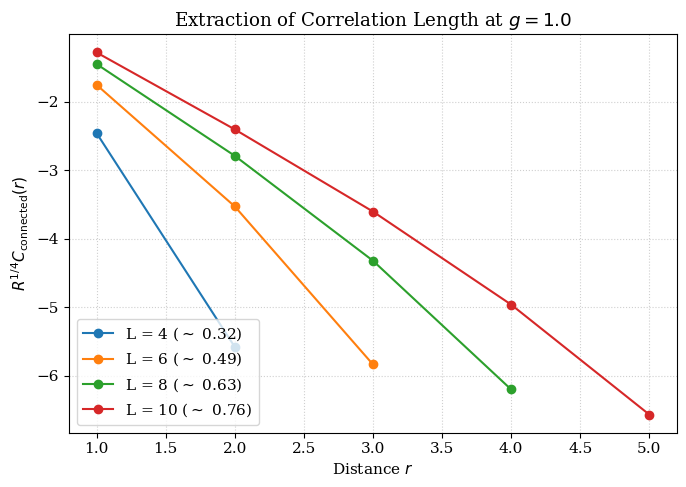

In [13]:
# --- Helper functions ---
def get_single_site_sz(site_idx, L):
    I = sp.eye(2, format='csr')
    sz = sp.csr_matrix([[1, 0], [0, -1]])
    op_list = [I] * L
    op_list[site_idx] = sz
    return reduce(sp.kron, op_list)

# --- Configuration ---
L_list = [4, 6, 8, 10]
g_target = 1.0
g_key = g_values[np.abs(g_values - g_target).argmin()]
filename = "quantum_ising_data.h5"

xi_dict = {}

plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 11, 'font.family': 'serif'})

for L in L_list:
    with h5py.File(filename, "r") as f:
        # Load states to construct the physical ground state
        states = f[f"L_{L}/g_{g_key}/states"][:]
        psi_0_raw = states[:, 0].reshape(-1, 1)
        psi_1_raw = states[:, 1].reshape(-1, 1)
        
        # Construct the physical symmetry-broken ground state for g < 1
        psi_0 = 1/sqrt(2) * (psi_0_raw - psi_1_raw)
        
    psi_conj_T = psi_0.conj().T
    sz_0 = get_single_site_sz(0, L)
    
    # 1. Compute 1-point expectation values <Sz_i>
    mag_0 = np.real((psi_conj_T @ sz_0 @ psi_0)[0, 0])
    
    local_mags = np.zeros(L)
    local_mags[0] = mag_0
    for r in range(1, L):
        sz_r = get_single_site_sz(r, L)
        local_mags[r] = np.real((psi_conj_T @ sz_r @ psi_0)[0, 0])
        
    # 2. Compute Connected Correlations: <Sz_0 Sz_r> - <Sz_0><Sz_r>
    # We fit up to L//2 to eliminate boundary reflection issues
    r_max = L // 2 
    r_values = np.arange(1, r_max + 1)
    c_connected = np.zeros(len(r_values))
    
    for idx, r in enumerate(r_values):
        sz_r = get_single_site_sz(r, L)
        sz0_szr = sz_0 @ sz_r
        
        total_corr = np.real((psi_conj_T @ sz0_szr @ psi_0)[0, 0])
        c_connected[idx] = total_corr - (local_mags[0] * local_mags[r])
        
    # 3. Transform data for fitting: y = ln(sqrt(r) * C_connected)
    # Filter out any non-positive values due to machine precision noise near 0
    valid_mask = c_connected > 0
    r_fit = r_values[valid_mask]
    c_fit = c_connected[valid_mask]
    
    y_values = r_fit**(1/4) * np.log(c_fit)
    
    # 4. Fit linear slope if we have enough points (requires at least 2 points)
    if len(r_fit) >= 2:
        slope, intercept = np.polyfit(r_fit, y_values, 1)
        xi = -1.0 / slope
        xi_dict[L] = xi
    else:
        # For extremely small L (like L=4), fallback to a basic two-point estimate if mask filtered points
        xi_dict[L] = np.nan 
        
    # Plot the scaling curves
    plt.plot(r_fit, y_values, 'o-', label=f"L = {L} ($\sim$ {xi_dict[L]:.2f})")

# --- Finalize Outputs and Plotting ---
# Calculate the average correlation length across valid system sizes
valid_xis = [val for val in xi_dict.values() if not np.isnan(val)]

print("--- Extracted Correlation Lengths---")
for L, xi in xi_dict.items():
    print(f"L = {L:2d}: \u03be = {xi:.4f}")

# Plot decorations
plt.title(f"Extraction of Correlation Length at $g = {g_target}$")
plt.xlabel("Distance $r$")
plt.ylabel("$R^{1/4} C_{\\mathrm{connected}}(r)$")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower left", frameon=True)
plt.tight_layout()
plt.show()

The correlation length from Onsager's exact solution is $\xi(g) = 1/|\ln(g)|$, which doesn't quite agree with the value here. Finite-size corrections may be large here.

## TSIM with symmetry-breaking

<font face="serif" color=lightblue> In this notebook, we look at the phases and phase transition of the 1D Transverse Field Ising Model (TSIM) with symmetry-breaking longitudinal field. The Hamiltonian matrix is:
$$ H = - \sum_{i = 1}^{L-1} \sigma_i^z \sigma_{i+1}^z - g\sum_{i=1}^{L} \sigma_i^x  \textcolor{pink}{-h \sum_{i=1}^L \sigma_i^z} $$



and repeat the analysis above:
- energy spectrum
- ground state degeneracies
- gaps and gap closing
- magnetization (order parameter/ long range order)
- two-point correlation function

In [14]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from functools import reduce # for reducing a list of matrices to a single matrix
import h5py # for storing data

In [15]:
# Construct Hamiltonian
def quantum_ising_broken_hamiltonian(L, g=0.5, h=0.5):
    # 1D Sparse Pauli matrices
    I = sp.eye(2, format='csr')
    sz = sp.csr_matrix([[1, 0], [0, -1]])
    sx = sp.csr_matrix([[0, 1], [1, 0]])
    
    H = sp.csr_matrix((2**L, 2**L))
    
    # 1. Interaction Terms: sz_i * sz_{i+1}
    sz_sz = sp.kron(sz, sz)
    for i in range(L - 1):
        # Identity padding before and after the interacting pair
        left_I = [I] * i
        right_I = [I] * (L - 2 - i)
        
        # Combine everything using reduce
        term = reduce(sp.kron, left_I + [sz_sz] + right_I)
        H -= term
        
    # 2. Transverse and Longitudinal Field Terms
    for i in range(L):
        left_I = [I] * i
        right_I = [I] * (L - 1 - i)
        
        g_term = reduce(sp.kron, left_I + [sx] + right_I)
        h_term = reduce(sp.kron, left_I + [sz] + right_I)

        H -= g * g_term + h * h_term
        
    return H

def save_broken_ising_data(filename, L, g, h, energies, states):
    """
    Saves eigenvalues and eigenvectors into a structured HDF5 file.
    """
    with h5py.File(filename, "a") as f:
        # Create a unique heirarchical path for this parameter set
        group_path = f"L_{L}/g_{g}/h_{h}"
        if group_path in f:
            del f[group_path]  # Overwrite cleanly if it already exists

        group = f.create_group(group_path)

        # Save the numerical arrays
        group.create_dataset("energies", data=energies, compression="gzip", compression_opts=4)
        group.create_dataset("states", data=states, compression="gzip", compression_opts=4)

        # Save metadata directly attached to this run
        group.attrs["L"] = L
        group.attrs["g"] = g
        group.attrs["h"] = h
        group.attrs["description"] = "Transverse-field Quantum Ising Model with symmetry breaking exact diagonalization"

def print_hdf5_metadata(name, obj):
    """Callback function to inspect each item in the HDF5 file."""
    # Indent based on hierarchy depth for readability
    depth = name.count('/')
    indent = "  " * depth
    
    if isinstance(obj, h5py.Group):
        print(f"{indent}📁 Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}📄 Dataset: {name} (shape={obj.shape}, dtype={obj.dtype})")
    
    # Check and print any metadata attributes attached to this object
    if len(obj.attrs) > 0:
        for key, val in obj.attrs.items():
            print(f"{indent}    ⚙️ Attribute -> {key}: {val}")

# Here is how you read the data
"""
filename = "quantum_ising_broken_data.h5"
with h5py.File(filename, "r") as f:
    # Access data directly like a dictionary
    read_energies = f["L_12/g_0.5/h_0.5/energies"][:]
    read_states = f["L_12/g_0.5/h_0.5/states"][:]
"""

# Here is how you read all the metadata and attributes
"""
# Open and inspect the file
filename = "quantum_ising_broken_data.h5"
with h5py.File(filename, "r") as f:
    print(f"--- Metadata Structure for {filename} ---")
    # Print root-level attributes if any exist
    for key, val in f.attrs.items():
        print(f"Root Attribute -> {key}: {val}")
        
    # Recursively visit all paths
    f.visititems(print_hdf5_metadata)
"""

'\n# Open and inspect the file\nfilename = "quantum_ising_broken_data.h5"\nwith h5py.File(filename, "r") as f:\n    print(f"--- Metadata Structure for {filename} ---")\n    # Print root-level attributes if any exist\n    for key, val in f.attrs.items():\n        print(f"Root Attribute -> {key}: {val}")\n\n    # Recursively visit all paths\n    f.visititems(print_hdf5_metadata)\n'

In [10]:
# Open and inspect the file
filename = "quantum_ising_broken_data.h5"
with h5py.File(filename, "r") as f:
    print(f"--- Metadata Structure for {filename} ---")
    # Print root-level attributes if any exist
    for key, val in f.attrs.items():
        print(f"Root Attribute -> {key}: {val}")
        
    # Recursively visit all paths
    f.visititems(print_hdf5_metadata)

--- Metadata Structure for quantum_ising_broken_data.h5 ---
📁 Group: L_10
  📁 Group: L_10/g_0.1
    📁 Group: L_10/g_0.1/h_-0.010101010101010055
        ⚙️ Attribute -> L: 10
        ⚙️ Attribute -> description: Transverse-field Quantum Ising Model with symmetry breaking exact diagonalization
        ⚙️ Attribute -> g: 0.1
        ⚙️ Attribute -> h: -0.010101010101010055
      📄 Dataset: L_10/g_0.1/h_-0.010101010101010055/energies (shape=(10,), dtype=float64)
      📄 Dataset: L_10/g_0.1/h_-0.010101010101010055/states (shape=(1024, 10), dtype=float64)
    📁 Group: L_10/g_0.1/h_-0.030303030303030276
        ⚙️ Attribute -> L: 10
        ⚙️ Attribute -> description: Transverse-field Quantum Ising Model with symmetry breaking exact diagonalization
        ⚙️ Attribute -> g: 0.1
        ⚙️ Attribute -> h: -0.030303030303030276
      📄 Dataset: L_10/g_0.1/h_-0.030303030303030276/energies (shape=(10,), dtype=float64)
      📄 Dataset: L_10/g_0.1/h_-0.030303030303030276/states (shape=(1024, 10),

### Spectrum

g = 0.5, 1.0

In [16]:
L_values_b = [8]
g_values_b = [1.5]
h_values = np.linspace(-1.0, 1.0, 100)
num_levels = 10

# """Uncomment when you want to generate and save new data. This will overwrite existing data for the same L and g values."""
# for L in L_values_b:
#     for g in g_values_b:
#         for h in h_values:
#             H = quantum_ising_broken_hamiltonian(L, g, h)
#             energies, states = spla.eigsh(H, k=num_levels, which='SA')

#             # Sort the energies and states
#             sort_indices = np.argsort(energies)
#             energies = energies[sort_indices]
#             states = states[:, sort_indices]

#             save_broken_ising_data("quantum_ising_broken_data.h5", L=L, g=g, h=h, energies=energies, states=states)
#             print(f"Saved data for L={L}, g={g}, h={h}")

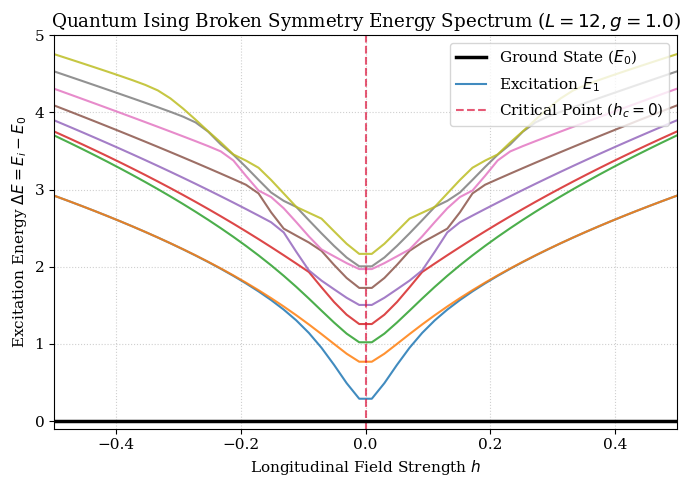

In [22]:
# -------------------------------------------------------------------
# 1. Loading HDF5 data and preparing for plotting
# -------------------------------------------------------------------
L = 12
g = 1.0
h_values = np.linspace(-1.0, 1.0, 100)
num_levels = 10
energies_grid = np.zeros((len(h_values), num_levels))
filename = "quantum_ising_broken_data.h5"
with h5py.File(filename, "r") as f:
    for idx, h in enumerate(h_values):
        for i in range(num_levels):
            energies_grid[idx, i] = f[f"L_{L}/g_{g}/h_{h}/energies"][:][i]


# -------------------------------------------------------------------
# 2. Plotting Code
# -------------------------------------------------------------------
# Set up a clean, professional LaTeX-style figure layout
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 11, 'font.family': 'serif'})

# Plot the excitation spectrum: E_i - E_0
# This normalizes the ground state to 0, making the gap visually obvious
ground_state_energy = energies_grid[:, 0]

for i in range(num_levels):
    excitation_energy = energies_grid[:, i] - ground_state_energy
    
    # Differentiate the ground state from excited states visually
    if i == 0:
        plt.plot(h_values, excitation_energy, label="Ground State ($E_0$)", 
                 color="black", lw=2.5, zorder=3)
    else:
        plt.plot(h_values, excitation_energy, label=f"Excitation $E_{i}$" if i==1 else "", 
                 lw=1.5, alpha=0.85)

# Highlight Physics Regimes & Critical Point
plt.axvline(x=0.0, color="crimson", linestyle="--", alpha=0.7, label="Critical Point ($h_c=0$)")

# Annotate the phases
# plt.text(0.2, 1.5, "Ferromagnetic\nOrder", fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.6))
# plt.text(1.4, 1.5, "Paramagnetic\nOrder", fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.6))
# plt.text(0.95, 0.3, "Gap Closing", color="crimson", fontsize=9, rotation=90, ha='right')

# Labels and Styling
plt.title(f"Quantum Ising Broken Symmetry Energy Spectrum ($L = {L}, g = {g}$)")
plt.xlabel("Longitudinal Field Strength $h$")
plt.ylabel("Excitation Energy $\Delta E = E_i - E_0$")
plt.xlim(-0.5, 0.5)
plt.ylim(-0.1, 5)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


#### Tracking all-spin-up state and all-spin-down state

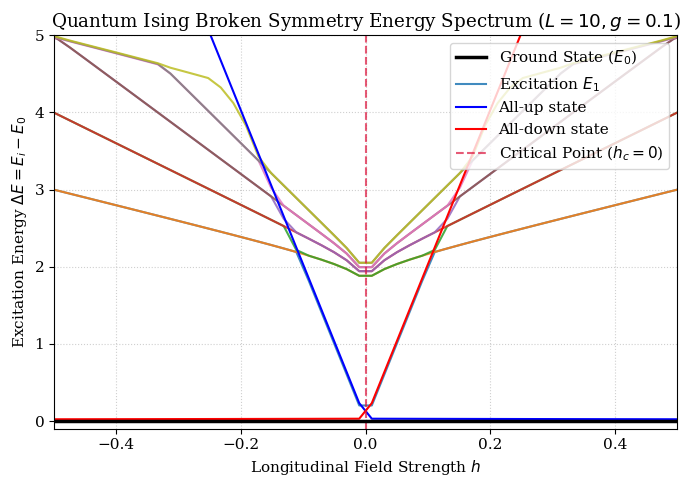

In [25]:
# -------------------------------------------------------------------
# 1. Preparation of data
# -------------------------------------------------------------------
L = 10
g = 0.1
h_values = np.linspace(-1.0, 1.0, 100)
num_levels = 10
energies_grid = np.zeros((len(h_values), num_levels))
filename = "quantum_ising_broken_data.h5"

# Prepare all-up states and all-down states
up_state = sp.csr_matrix([1, 0]).reshape(-1, 1)
down_state = sp.csr_matrix([0, 1]).reshape(-1, 1)

all_up_state = reduce(sp.kron, [up_state]*L)
all_down_state = reduce(sp.kron, [down_state]*L)

E_up = []
E_down = []
with h5py.File(filename, "r") as f:
    for idx, h in enumerate(h_values):
        # Load HDF5 data
        for i in range(num_levels):
            energies_grid[idx, i] = f[f"L_{L}/g_{g}/h_{h}/energies"][:][i]
        
        # Compute the all_up energy
        H = quantum_ising_broken_hamiltonian(L, g, h)
        E_up.append((all_up_state.conj().T @ H @ all_up_state).toarray()[0, 0])
        E_down.append((all_down_state.conj().T @ H @ all_down_state).toarray()[0, 0])

# -------------------------------------------------------------------
# 2. Plotting Code
# -------------------------------------------------------------------
# Set up a clean, professional LaTeX-style figure layout
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 11, 'font.family': 'serif'})

# Plot the excitation spectrum: E_i - E_0
# This normalizes the ground state to 0, making the gap visually obvious
ground_state_energy = energies_grid[:, 0]
E_up_corrected = np.array(E_up) - ground_state_energy
E_down_corrected = np.array(E_down) - ground_state_energy

for i in range(num_levels):
    excitation_energy = energies_grid[:, i] - ground_state_energy
    
    # Differentiate the ground state from excited states visually
    if i == 0:
        plt.plot(h_values, excitation_energy, label="Ground State ($E_0$)", 
                 color="black", lw=2.5, zorder=3)
    else:
        plt.plot(h_values, excitation_energy, label=f"Excitation $E_{i}$" if i==1 else "", 
                 lw=1.5, alpha=0.85)

# Plot the all-up energy as function of h
plt.plot(h_values, E_up_corrected, label="All-up state", color="blue")
plt.plot(h_values, E_down_corrected, label="All-down state", color="red")

# Highlight Physics Regimes & Critical Point
plt.axvline(x=0.0, color="crimson", linestyle="--", alpha=0.7, label="Critical Point ($h_c=0$)")

# Annotate the phases
# plt.text(0.2, 1.5, "Ferromagnetic\nOrder", fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.6))
# plt.text(1.4, 1.5, "Paramagnetic\nOrder", fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.6))
# plt.text(0.95, 0.3, "Gap Closing", color="crimson", fontsize=9, rotation=90, ha='right')

# Labels and Styling
plt.title(f"Quantum Ising Broken Symmetry Energy Spectrum ($L = {L}, g = {g}$)")
plt.xlabel("Longitudinal Field Strength $h$")
plt.ylabel("Excitation Energy $\Delta E = E_i - E_0$")
plt.xlim(-0.5, 0.5)
plt.ylim(-0.1, 5)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


- Level crossing happens between all-up and all-down states at all finite $L$'s because $h$ prefers over another
- This is first-order phase transition due to the sudden change in magnetization

### Magnetization

#### Average magnetization with weak symmetry-breaking field

Data for L=4 has been plotted.
Data for L=6 has been plotted.
Data for L=8 has been plotted.
Data for L=10 has been plotted.


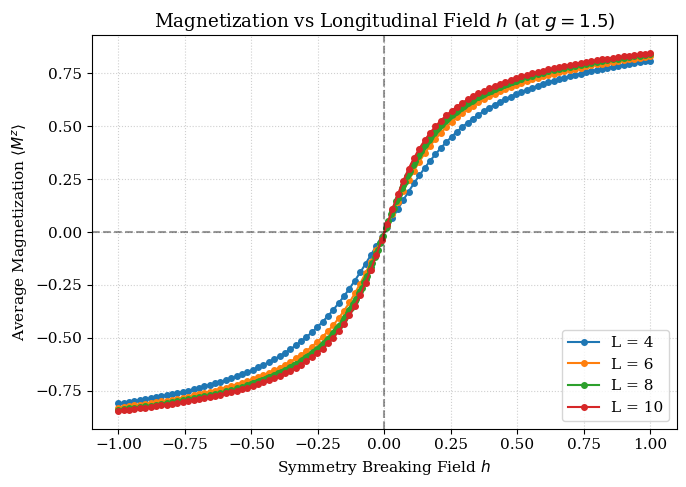

In [25]:
def get_single_site_sz(site_idx, L):
    """Constructs the sparse matrix for sigma^z acting on a single site."""
    I = sp.eye(2, format='csr')
    sz = sp.csr_matrix([[1, 0], [0, -1]])

    op_list = [I] * L
    op_list[site_idx] = sz
    return reduce(sp.kron, op_list)

# --- Configuration ---
L_list = [4, 6, 8, 10]
g = 1.5
# Assuming you save your new field-sweep data to a file structured like this:
filename = "quantum_ising_broken_data.h5" 

plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 11, 'font.family': 'serif'})

# --- Loop over each system size to plot numerical data ---
for L in L_list:
    avg_mags_for_L = []
    h_plotted = []
    
    with h5py.File(filename, "r") as f:
        # Pull the available h group keys for the given L at g=0.1
        # Expecting group structure like: f"L_{L}/g_0.1/h_0.001"
        g_ref = f[f"L_{L}/g_{g}"]
        h_groups = [k for k in g_ref.keys() if k.startswith("h_")]
        # Sort key by actual float value of h
        h_groups.sort(key=lambda x: float(x.split('_')[1]))
        
        for h_str in h_groups:
            h_val = float(h_str.split('_')[1])
            h_plotted.append(h_val)
            
            # Since h explicitly breaks symmetry, states[:, 0] is directly 
            # the unique, physical ground state picked out by the field.
            states = g_ref[f"{h_str}/states"][:]
            physical_state = states[:, 0].reshape(-1, 1) 
            
            total_mag_for_h = 0.0
            psi_conj_T = physical_state.conj().T
            
            for i in range(L):
                # Using your existing site matrix builder
                sz_i = get_single_site_sz(i, L)
                mag_i = np.real((psi_conj_T @ sz_i @ physical_state)[0, 0])
                total_mag_for_h += mag_i
                
            # Do NOT use abs() here if you sweep h from negative to positive values
            avg_mag = total_mag_for_h / L
            avg_mags_for_L.append(avg_mag)
            
    plt.plot(h_plotted, avg_mags_for_L, 'o-', label=f"L = {L}", markersize=4, lw=1.5)
    print(f"Data for L={L} has been plotted.")

# --- Plot Styling ---
plt.axvline(x=0.0, color="black", linestyle="--", alpha=0.4)
plt.axhline(y=0.0, color="black", linestyle="--", alpha=0.4)
plt.title(f"Magnetization vs Longitudinal Field $h$ (at $g = {g}$)")
plt.xlabel("Symmetry Breaking Field $h$")
plt.ylabel(r"Average Magnetization $\langle M^z \rangle$")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.savefig(f"magnetization_vs_h_g={g}.pdf", bbox_inches='tight')
plt.show()
plt.show()